In [22]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm  # for progress bar
from torch.cuda.amp import GradScaler, autocast
from datetime import datetime

from TtoGmodel_10 import TextToGraphTransformer

In [23]:
from Circuits import Circuits
circuits= Circuits()

Loading dataset files...
Loaded dataset files successfully.


In [24]:
print(circuits.component_lists[0])
print(circuits.graphs[0])

['VDD', 'VSS', 'VIN1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [25]:
def collate_fn(batch):
    seqs, mats = zip(*batch)

    # Convert sequences to torch tensors
    seqs = [torch.tensor(seq, dtype=torch.long) for seq in seqs]

    # Convert adjacency matrices (NumPy -> PyTorch)
    mats = [torch.tensor(mat, dtype=torch.float32) for mat in mats]

    # Get max sizes
    max_seq_len = max(len(seq) for seq in seqs)
    max_nodes = max(mat.size(0) for mat in mats)

    # Pad sequences
    padded_seqs = torch.stack([
        F.pad(seq, (0, max_seq_len - len(seq)), value=0)
        for seq in seqs
    ])

    # Pad adjacency matrices
    padded_mats = torch.stack([
        F.pad(mat, (0, max_nodes - mat.size(1), 0, max_nodes - mat.size(0)), value=0)
        for mat in mats
    ])

    seq_lengths = torch.tensor([len(seq) for seq in seqs])

    return padded_seqs, padded_mats, seq_lengths


In [26]:
from sklearn.model_selection import train_test_split

dataset = list(zip(circuits.component_indices, circuits.graphs))
# Split dataset into training and testing sets
train_data, test_data = train_test_split(dataset, test_size=0.1, random_state=42)
loader = torch.utils.data.DataLoader(train_data, batch_size=12, shuffle=True, collate_fn=collate_fn)


In [27]:
print(circuits.component_indices[0])
print(circuits.graphs[0])


[210, 551, 298, 466, 47, 611, 22, 749]
[[0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1]
 [1 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0]
 [0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0]]


In [28]:
# Initialize model parameters
vocab_size = len(circuits.vocab)  # Number of unique components
embedding_dim = 128
hidden_dim = 256
num_heads = 8
num_layers = 4
dropout = 0.1

# Initialize the model
model = TextToGraphTransformer(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

TextToGraphTransformer(
  (embedding): Embedding(892, 128, padding_idx=0)
  (positional_encoding): SinusoidalPositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): R

In [29]:
def calculate_test_accuracy(model, test_data, device, threshold=0.5):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for input_seq, true_adj in test_data:
            input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)
            seq_len = input_tensor.size(1)
            seq_mask = (input_tensor != PAD_TOKEN_ID)

            logits = model(input_tensor, seq_mask)
            probs = torch.sigmoid(logits.squeeze(0))  # Shape: (S, S)
            predicted_adj = (probs > threshold).float().cpu().numpy()

            # Compare predicted adjacency matrix with the ground truth
            correct += (predicted_adj == true_adj).sum()
            total += true_adj.size

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")


In [30]:
def calculate_test_loss(model, test_data, device, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for input_seqs, adj_mats, seq_lengths in DataLoader(test_data, batch_size=12, collate_fn=collate_fn):
            input_seqs = input_seqs.to(device, non_blocking=True)
            adj_mats = adj_mats.to(device, non_blocking=True)

            seq_mask = (input_seqs != PAD_TOKEN_ID)  # [B, S]
            predicted_logits = model(input_seqs, seq_mask)

            # Efficient masking (flatten first)
            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)                   # [B*S*S]
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])
            total_loss += loss.item()

    avg_loss = total_loss / len(test_data)
    print(f"Test Loss: {avg_loss:.4f}")
    return avg_loss


In [31]:
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import autocast, GradScaler

PAD_TOKEN_ID = 0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()  # For mixed-precision training (optional)

num_epochs = 100
dataloader = loader
save_every = 10 # Save every N epochs

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False)

    for input_seqs, adj_mats, seq_lengths in progress_bar:
        input_seqs = input_seqs.to(device, non_blocking=True)
        adj_mats = adj_mats.to(device, non_blocking=True)
        seq_lengths = seq_lengths.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():  # Mixed-precision forward pass (optional)
            seq_mask = (input_seqs != PAD_TOKEN_ID)  # [B, S]
            predicted_logits = model(input_seqs, seq_mask)


            # Efficient masking (flatten first)
            mask = (input_seqs != PAD_TOKEN_ID)
            mask2d = mask.unsqueeze(2) & mask.unsqueeze(1)
            mask_flat = mask2d.view(-1)                   # [B*S*S]
            pred_flat = predicted_logits.view(-1)
            true_flat = adj_mats.view(-1)

            loss = criterion(pred_flat[mask_flat], true_flat[mask_flat])

        # Backprop with mixed precision
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.detach().item()  # Detach to avoid memory buildup
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"[Epoch {epoch}] Avg Loss: {avg_loss:.4f}")
    calculate_test_loss(model, test_data, device, criterion)
    if epoch % save_every == 0:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = f"./Saves/toGmodel_epoch{epoch}_{timestamp}.pth"
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab_size': vocab_size,
            'embedding_dim': embedding_dim,
            'hidden_dim': hidden_dim,
            'num_heads': num_heads,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': 1e-4,
        }
        torch.save(checkpoint, save_path)
        print(f"💾 Checkpoint saved at epoch {epoch} → {save_path}")

# Save model
torch.save(model.state_dict(), 'TextToGraphTransformer.pth')


C:\Users\MSI\AppData\Local\Temp\ipykernel_10012\1230772804.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # For mixed-precision training (optional)
Epoch 1:   0%|          | 0/252 [00:00<?, ?it/s]C:\Users\MSI\AppData\Local\Temp\ipykernel_10012\1230772804.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # Mixed-precision forward pass (optional)


[Epoch 1] Avg Loss: 0.1444
Test Loss: 0.0103


[Epoch 2] Avg Loss: 0.1164
Test Loss: 0.0098


[Epoch 3] Avg Loss: 0.1091
Test Loss: 0.0087


[Epoch 4] Avg Loss: 0.0915
Test Loss: 0.0067


...

[Epoch 25] Avg Loss: 0.0234
Test Loss: 0.0020


[Epoch 26] Avg Loss: 0.0227
Test Loss: 0.0020


[Epoch 27] Avg Loss: 0.0224
Test Loss: 0.0020


[Epoch 28] Avg Loss: 0.0222
Test Loss: 0.0020


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import precision_score, confusion_matrix

# Select a sample from test_data
sample_seq, sample_adj = test_data[4]  # Replace 0 with the desired index

# Convert the sample sequence to a tensor
input_tensor = torch.tensor(sample_seq, dtype=torch.long).unsqueeze(0).to(device)  # [1, S]

# Generate the sequence mask
seq_mask = (input_tensor != PAD_TOKEN_ID)

# Evaluate the model
model.eval()
with torch.no_grad():
    logits = model(input_tensor, seq_mask)
    probs = torch.sigmoid(logits.squeeze(0))  # Shape: (S, S)
    predicted_adj = (probs > 0.5).float().cpu().numpy()

# Print the results
print("Input Sequence:", sample_seq)
print("True Adjacency Matrix:")
print(sample_adj)
print("Predicted Adjacency Matrix:")
print(predicted_adj)

# Flatten the true and predicted adjacency matrices for comparison
true_flat = sample_adj.flatten()
predicted_flat = predicted_adj.flatten()

# Calculate precision
precision = precision_score(true_flat, predicted_flat, zero_division=0)
print("Precision:", precision)

# Calculate confusion matrix
conf_matrix = confusion_matrix(true_flat, predicted_flat)
print("Confusion Matrix:")
print(conf_matrix)

Input Sequence: [210, 551, 298, 422, 673, 506, 776, 501, 861, 548, 414, 224, 591, 338, 343, 379, 275, 886, 181, 199, 722, 35, 713, 761, 480, 780, 680, 466, 47, 611, 22, 749, 308, 56, 889, 68, 816, 63, 540, 717, 648, 6, 629, 324, 618, 245, 430, 260, 481, 864, 887, 27, 212, 261, 815, 125, 519, 330, 509, 346, 488, 803, 435, 687, 233, 874, 48, 688, 838, 596, 531, 814, 5, 17, 552, 806, 553, 615, 652, 622, 602, 203, 870, 560, 432, 790, 363, 124, 140, 337, 8, 301, 82, 836, 436, 541]
True Adjacency Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 0]
 [0 1 0 ... 1 0 0]]
Predicted Adjacency Matrix:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 1.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]]
Precision: 0.9926470588235294
Confusion Matrix:
[[8906    2]
 [  38  270]]


In [ ]:
def evaluate_adjacency_matrix(model, input_seq, vocab, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)  # [1, S]
        seq_len = input_tensor.size(1)
        dummy_adj = torch.zeros((1, seq_len, seq_len), dtype=torch.float).to(device)
        dummy_lengths = torch.tensor([seq_len]).to(device)  # Sequence length for this input

        # Pass both input_tensor and dummy_lengths to the model
        seq_mask = (input_tensor != PAD_TOKEN_ID)
        logits = model(input_tensor, seq_mask)

        
        probs = torch.sigmoid(logits.squeeze(0))  # Shape: (S, S)
        binary_adj = (probs > threshold).float()

        print("\nPredicted Adjacency Matrix (Binary, N x N):")
        print(binary_adj.cpu().numpy())


In [ ]:
ex_index = 2
sample_input = circuits.component_indices[ex_index]
print("Sample Input Sequence:", sample_input)
print("Sample Input Sequence:", circuits.component_lists[ex_index])
print("Actual Adjacency Matrix:")
print(circuits.graphs[ex_index])
evaluate_adjacency_matrix(model, sample_input, circuits.vocab, device)

Sample Input Sequence: [210, 551, 298, 422, 673, 501, 861, 548, 414, 224, 466, 47, 611, 22, 749]
Sample Input Sequence: ['VDD', 'VSS', 'VIN1', 'VOUT1', 'VB1', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B']
Actual Adjacency Matrix:
[[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]]

Predicted Adjacency Matrix (Binary, N x N):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [ ]:
def load_checkpoint(path, device='cuda'):
    checkpoint = torch.load(path, map_location=device)

    model = TextToGraphTransformer(
        vocab_size=checkpoint['vocab_size'],
        embedding_dim=checkpoint['embedding_dim'],
        hidden_dim=checkpoint['hidden_dim'],
        num_heads=checkpoint['num_heads'],
        num_layers=checkpoint['num_layers'],
        dropout=checkpoint['dropout']
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])

    optimizer = torch.optim.Adam(model.parameters(), lr=checkpoint['learning_rate'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f"✅ Loaded model from {path} (epoch {checkpoint['epoch']})")
    return model, optimizer, checkpoint['epoch']


In [ ]:
# Example usage

# 1. Path to saved checkpoint
file_name = "toGmodel_epoch20_20250422_224929.pth"
checkpoint_path = './Saves/' + file_name # Replace with your file

# 2. Load the model and optimizer
model, optimizer, start_epoch = load_checkpoint(checkpoint_path, device=device)


ex_index = 3300
sample_input = circuits.component_indices[ex_index]
print("Sample Input Sequence:", circuits.component_lists[ex_index])
print("Actual Adjacency Matrix:")
print(circuits.graphs[ex_index])
evaluate_adjacency_matrix(model, circuits.component_lists[ex_index][0:-3], circuits.vocab, device)



✅ Loaded model from ./Saves/toGmodel_epoch20_20250422_224929.pth (epoch 20)
Sample Input Sequence: ['VDD', 'VSS', 'VIN1', 'VIN2', 'VOUT1', 'VB1', 'VB2', 'VCLK1', 'VCLK2', 'VCLK3', 'VCLK4', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'NM2', 'NM2_D', 'NM2_G', 'NM2_S', 'NM2_B', 'NM3', 'NM3_D', 'NM3_G', 'NM3_S', 'NM3_B', 'NM4', 'NM4_D', 'NM4_G', 'NM4_S', 'NM4_B', 'NM5', 'NM5_D', 'NM5_G', 'NM5_S', 'NM5_B', 'PM1', 'PM1_D', 'PM1_G', 'PM1_S', 'PM1_B', 'PM2', 'PM2_D', 'PM2_G', 'PM2_S', 'PM2_B', 'PM3', 'PM3_D', 'PM3_G', 'PM3_S', 'PM3_B', 'PM4', 'PM4_D', 'PM4_G', 'PM4_S', 'PM4_B', 'NM6', 'NM6_D', 'NM6_G', 'NM6_S', 'NM6_B', 'NM7', 'NM7_D', 'NM7_G', 'NM7_S', 'NM7_B', 'PM5', 'PM5_D', 'PM5_G', 'PM5_S', 'PM5_B', 'PM6', 'PM6_D', 'PM6_G', 'PM6_S', 'PM6_B', 'NM8', 'NM8_D', 'NM8_G', 'NM8_S', 'NM8_B', 'NM9', 'NM9_D', 'NM9_G', 'NM9_S', 'NM9_B', 'NM10', 'NM10_D', 'NM10_G', 'NM10_S', 'NM10_B', 'NM11', 'NM11_D', 'NM11_G', 'NM11_S', 'NM11_B', 'NM12', 'NM12_D', 'NM12_G', 'NM12_S', 'NM12_B', 'NM13', 'NM13_D', 'NM1

C:\Users\MSI\AppData\Local\Temp\ipykernel_10012\3424363509.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


ValueError: too many dimensions 'str'

In [ ]:
ex_index = 1
sample_input = circuits.component_indices[ex_index]
print("Sample Input Sequence:", circuits.component_lists[ex_index][0:-3])
print("Actual Adjacency Matrix:")
print(circuits.graphs[ex_index])

Sample Input Sequence: ['VDD', 'VSS', 'VOUT1', 'NM1', 'NM1_D', 'NM1_G', 'NM1_S', 'NM1_B', 'R1', 'R1_P', 'R1_N']
Actual Adjacency Matrix:
[[0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 0 1]
 [0 0 0 0 0 0 1 0 0 1 0 0 1 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [0 0 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 1 0 0]]


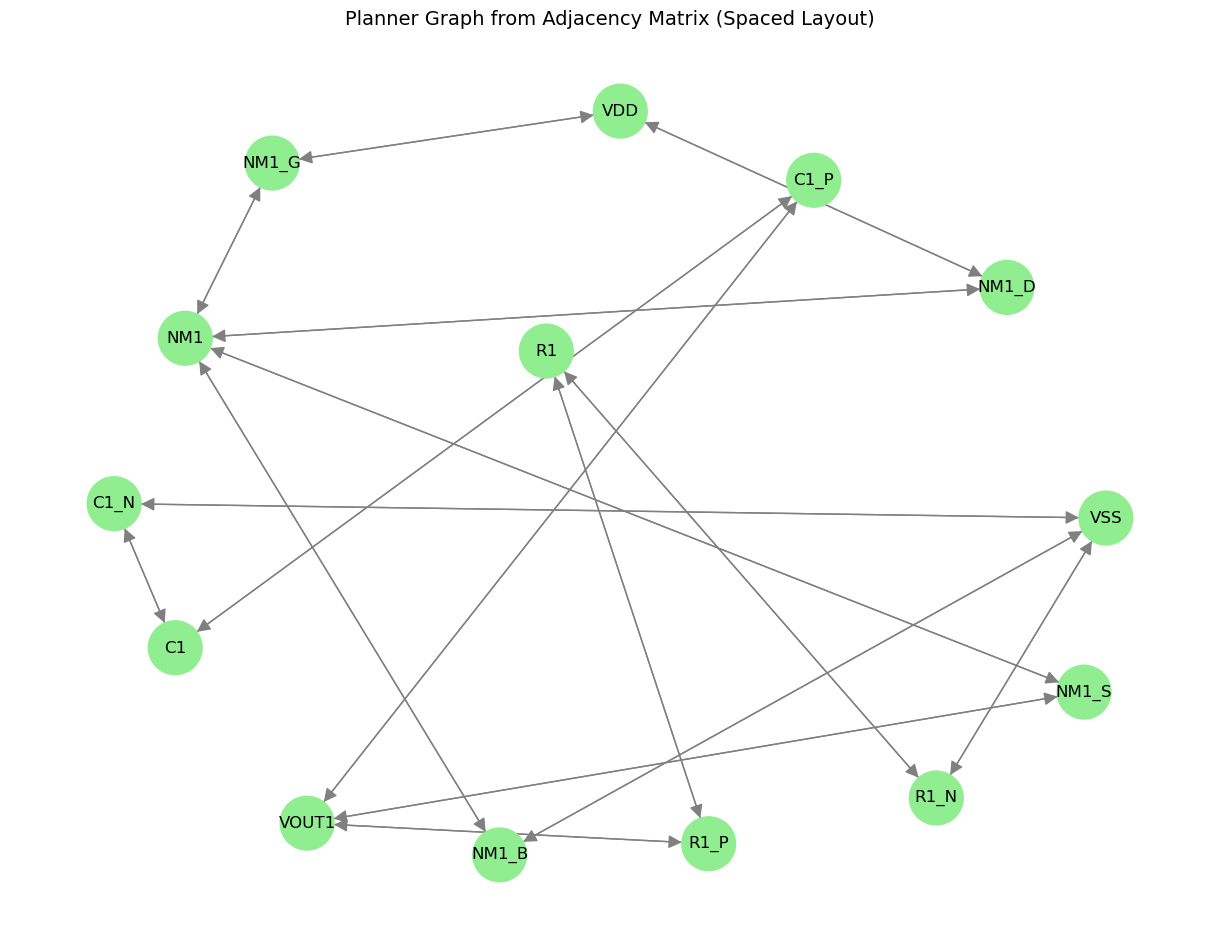

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_planner_from_adj_matrix(nodes, adj_matrix, spacing=2.0):
    """
    Visualize a planner graph with more spacing between nodes for clarity.

    :param nodes: List of node labels.
    :param adj_matrix: 2D list or numpy array.
    :param spacing: Float, layout spacing (default is 2.0).
    """
    G = nx.DiGraph()

    # Add nodes
    for node in nodes:
        G.add_node(node)

    # Add edges based on adjacency matrix
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if adj_matrix[i][j] != 0:
                G.add_edge(nodes[i], nodes[j])

    # Color nodes based on type
    colors = ['skyblue' if n.startswith('S') else 'lightgreen' for n in G.nodes]

    # Use spring layout with more spacing
    pos = nx.spring_layout(G, seed=42, k=spacing)

    # Draw graph
    plt.figure(figsize=(12, 9))
    nx.draw(G, pos, with_labels=True, node_color=colors, edge_color='gray',
            node_size=1500, font_size=12, arrows=True, arrowsize=20)
    plt.title("Planner Graph from Adjacency Matrix (Spaced Layout)", fontsize=14)
    plt.show()

# Example graph
nodes = circuits.component_lists[ex_index]
adj_matrix = circuits.graphs[ex_index]

visualize_planner_from_adj_matrix(nodes, adj_matrix, spacing=2.5)
